In [579]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller

## Data collection 

In [580]:
tickers="AAPL, MSFT, AMZN, NVDA, GOOGL, GOOG, META, TSLA, BRK-B, UNH, JNJ, JPM, V, PG, XOM, HD, MA, CVX, MRK, ABBV, AVGO, COST, KO, PEP, WMT, BAC, CRM, DIS, ORCL, TMO, ACN, NFLX, LIN, ABT, MCD, CSCO, DHR, VZ, WFC, INTU, CMCSA, ADP, TXN, IBM, PM, NKE, RTX, HON, QCOM, UPS, LOW, BMY, AMGN, SPGI, SCHW, CAT, GS, BLK, MDLZ, CVS, AXP, DE, MS, AMT, C, BA, T, ISRG, NOW, GILD, LMT, ADI, MMM, MO, SYK, ZTS, CB, TJX, ETN, CI, SO, VRTX, PGR, MU, PLD, REGN, USB, WM, BK, KLAC, LRCX, FIS, ICE, APD, HCA, SHW, EL, NOC"
tickers_list = tickers.split(", ")

In [581]:
df = yf.download(
    tickers,
    start="2014-01-01",
    end="2019-12-30",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [582]:
df_test = yf.download(
    tickers,
    start="2019-12-30",
    interval="1d",
    auto_adjust=True,
    group_by="tickers",
    threads=True
)

[*********************100%***********************]  98 of 98 completed


In [583]:
print('The df_test shape is:', df_test.shape)
print('The df shape is:', df.shape)

The df_test shape is: (1593, 490)
The df shape is: (1508, 490)


## Data Cleaning 

In [584]:
df = df.xs("Close", axis=1, level=1).pct_change().dropna()
df=pd.DataFrame(df)
df_test = df_test.xs("Close", axis=1, level=1).pct_change().dropna()
df_test=pd.DataFrame(df_test)

#### Row Return to Log Return

In [585]:
import numpy as np
returns = np.log(1+df)
returns_F = np.log(1+df_test)
returns.head()

Ticker,GOOGL,LRCX,NVDA,CI,MRK,BAC,SCHW,T,C,ZTS,...,META,RTX,AAPL,PLD,ACN,BMY,HON,CVX,AXP,AMT
Date,,,,,,,,,,,,,,,,,,,,,
2014-01-03,-0.007322,-0.000185,-0.012052,0.002318,0.004838,0.019071,0.003093,-0.004301,0.021388,-0.009626,...,-0.002745,0.003638,-0.022211,0.008901,0.003322,0.011036,0.002212,0.001690,0.003237,0.002891
2014-01-06,0.011088,-0.012875,0.013312,-0.003130,0.000201,0.015120,-0.003481,0.004587,0.007649,-0.002186,...,0.047253,-0.000975,0.005438,0.004287,-0.010622,-0.003982,-0.000995,-0.002657,-0.000446,0.006379
2014-01-07,0.019095,0.012318,0.016240,0.025449,0.007412,-0.009650,-0.010516,-0.000286,0.006852,0.003745,...,0.012509,0.006364,-0.007178,0.008785,0.012095,-0.001521,0.004083,0.008431,-0.003797,0.013747
2014-01-08,0.002079,0.004996,0.013539,-0.004993,-0.006407,0.004837,0.011677,-0.002944,0.011561,-0.011278,...,0.005338,0.001232,0.006313,-0.001326,0.007698,0.016230,-0.003972,-0.014335,0.003136,0.007841
2014-01-09,-0.009677,0.000370,-0.037999,0.024051,-0.005438,0.014966,0.000387,-0.020656,0.007090,0.006907,...,-0.017497,0.000528,-0.012853,-0.012821,0.009691,0.029693,0.000331,0.000000,-0.005945,0.001951


In [586]:
# align columns of returns_F to match training scaler
returns_F = returns_F[returns.columns]

#### Average Correlation between  the selected assets

In [587]:
returns.corr().mean().mean()

np.float64(0.3590831849152442)

## Checking the stationarity

In [588]:
results = returns.apply(lambda col: adfuller(col)[1])  # Extract p-values for each asset's returns
results = pd.Series(results, index=returns.columns)
results.max()

np.float64(6.119961797689399e-22)

## PCA application

In [589]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [590]:
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)

In [591]:
pca = PCA()
pca.fit(returns_scaled)

PCA()

In [592]:
eigenvalues      = pd.Series(pca.explained_variance_)          # variance of each PC
eigenvectors     = pd.DataFrame(pca.components_)                  # shape: (N_components, N_assets)
explained_ratio  = pd.Series(pca.explained_variance_ratio_)    # % variance per PC
cumulative_var   = np.cumsum(explained_ratio)

In [593]:
eigenvalues.head()

0    36.331889
1     4.553324
2     3.771432
3     2.425867
4     1.966650
dtype: float64

In [594]:
eigenvectors.head()

,0,1,2,3,4,5,6,7,8,9,...,88,89,90,91,92,93,94,95,96,97
0,0.109533,0.102798,0.089194,0.072885,0.091517,0.116872,0.116869,0.078051,0.124323,0.093985,...,0.088390,0.116303,0.100517,0.089577,0.123952,0.074297,0.131615,0.096406,0.110367,0.072886
1,-0.045033,-0.102313,-0.111185,-0.015053,0.105224,-0.192493,-0.170603,0.119639,-0.155549,0.024142,...,-0.057475,0.004419,-0.052321,0.170042,0.034900,0.034638,0.009179,-0.009060,-0.066036,0.191821
2,-0.183102,-0.124650,-0.145281,-0.010227,0.007312,0.188859,0.145629,0.111190,0.172647,-0.100224,...,-0.193942,0.051232,-0.115760,-0.021844,-0.037885,-0.035537,0.043630,0.114829,0.069172,-0.074678
3,-0.021780,-0.165670,-0.155413,0.200322,0.217723,0.059487,0.054446,-0.040842,0.033161,0.142765,...,-0.008219,-0.082278,-0.108434,-0.022444,-0.037428,0.204652,-0.059389,-0.074429,0.047037,-0.032190
4,-0.174706,0.163986,0.058807,0.087968,0.095045,-0.105734,-0.063135,0.080077,-0.095469,0.073371,...,-0.152896,0.048092,0.030006,-0.037526,-0.058034,0.111812,0.063423,0.134222,-0.069024,-0.084631


In [595]:
explained_ratio

0     0.370488
1     0.046432
2     0.038458
3     0.024737
4     0.020055
        ...   
93    0.001307
94    0.001179
95    0.001145
96    0.001018
97    0.000076
Length: 98, dtype: float64

In [596]:
cumulative_var.tail()

93    0.996583
94    0.997761
95    0.998906
96    0.999924
97    1.000000
dtype: float64

## The Marchenko-Pastur filter 

In [597]:
T, N = returns_scaled.shape
lambda_noise = (1 + np.sqrt(N / T))**2
signal_eigenvalues  = eigenvalues[eigenvalues.values > lambda_noise].reset_index(drop=True)
signal_eigenvectors = eigenvectors[eigenvalues.values > lambda_noise]  # shape: (n_signal, N_assets)
n_signal = np.sum(eigenvalues.values > lambda_noise)
print(f"T={T}, N={N}")
print(f"Noise threshold (lambda_max): {lambda_noise:.4f}")
print(f"Signal PCs: {n_signal}")

T=1507, N=98
Noise threshold (lambda_max): 1.5750
Signal PCs: 6


## Equal weighted Portfolio 

#### Construction

In [598]:
N = returns.shape[1]
weights = np.ones(N) / N

In [599]:
portfolio_returns = returns_F @ weights
portfolio_returns.columns = ['Returns']
portfolio_returns.describe()

count    1592.000000
mean        0.000485
std         0.012465
min        -0.131752
25%        -0.004472
50%         0.000672
75%         0.006205
max         0.097721
dtype: float64

<Axes: title={'center': 'Equal-Weighted Portfolio Returns'}, xlabel='Date'>

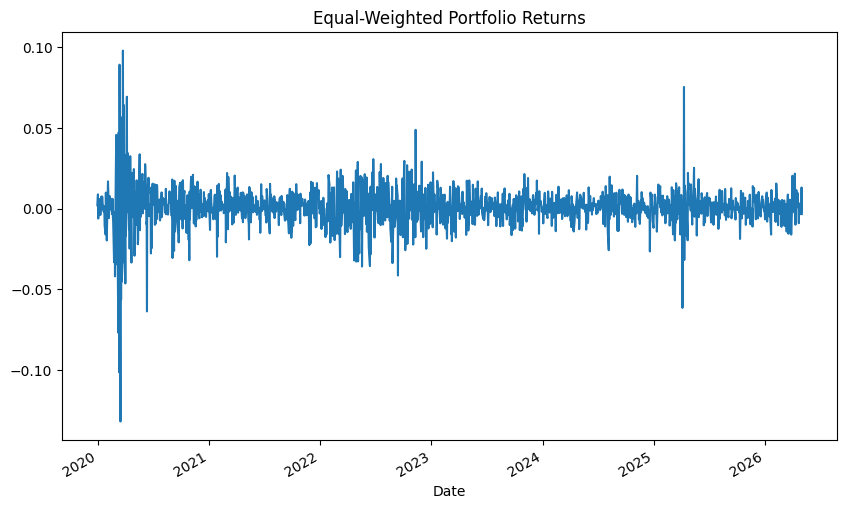

In [600]:
portfolio_returns.plot(title='Equal-Weighted Portfolio Returns', figsize=(10,6))

<Axes: title={'center': 'Cumulative Returns of Equal-Weighted Portfolio'}, xlabel='Date'>

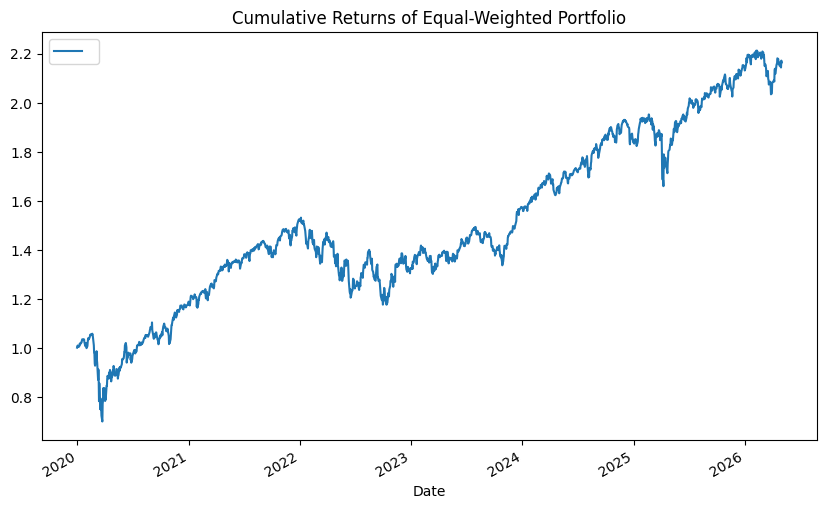

In [601]:
cum_returns = np.exp(portfolio_returns.cumsum()) # cumulative product of (1 + returns) to get wealth index
cum_returns.plot(title='Cumulative Returns of Equal-Weighted Portfolio', figsize=(10,6),legend=True)

#### Maximum Drawdown / Sharp ratio

In [602]:
wealth_index=cum_returns
previous_peak = wealth_index.cummax()

<Axes: title={'center': 'Wealth Index and Drawdown'}, xlabel='Date'>

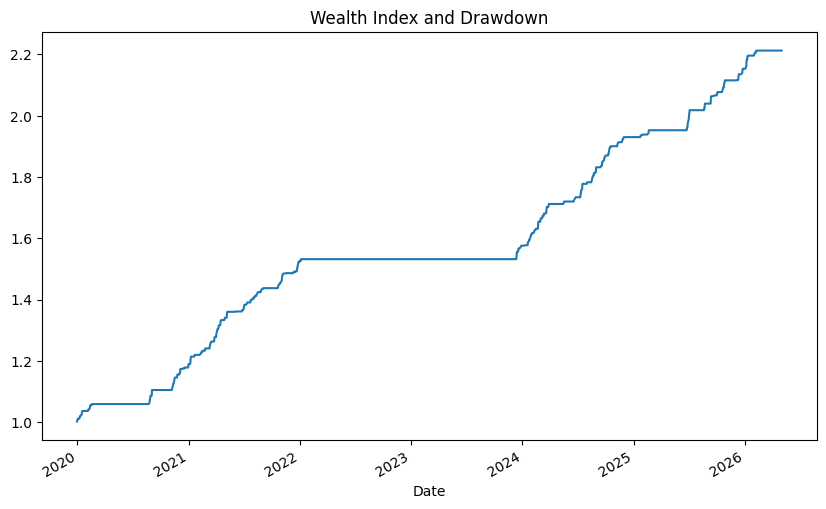

In [603]:
previous_peak.plot(title='Wealth Index and Drawdown', figsize=(10,6), label='Wealth Index')

In [604]:
ew_drawdown = (wealth_index - previous_peak) / previous_peak
print('Max drawdown of', ew_drawdown.min().round(2))

Max drawdown of -0.34


<Axes: title={'center': 'Drawdown'}, xlabel='Date'>

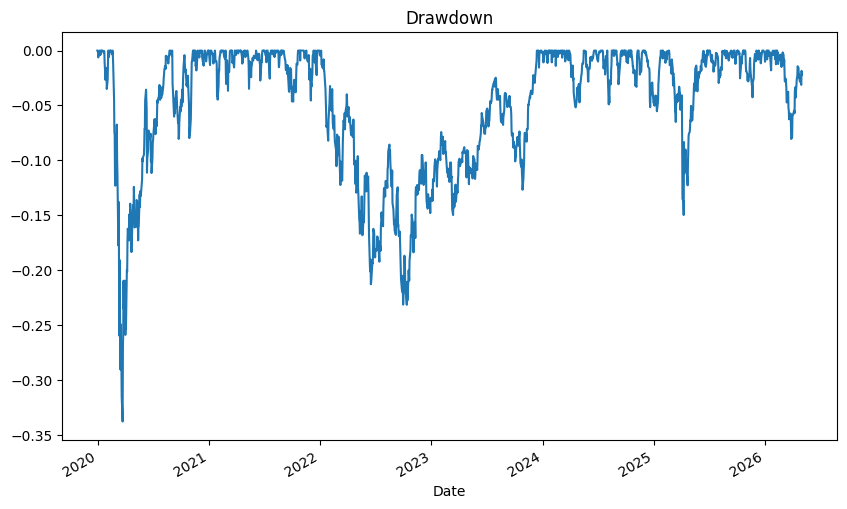

In [605]:
ew_drawdown.plot(title="Drawdown", figsize=(10,6))

In [606]:
ew_ann_return = portfolio_returns.mean() * 252
ew_ann_vol = portfolio_returns.std() * np.sqrt(252)
risk_free=0 ## Assuming risk-free rate is 0 for simplicity; adjust as needed
ew_sharpe = (ew_ann_return - risk_free) / ew_ann_vol   

print("Equal-weighted portfolio")
print(f"Annualized return      : {ew_ann_return:.4f}")
print(f"Annualized volatility  : {ew_ann_vol:.4f}")
print(f"Sharpe ratio           : {ew_sharpe:.4f}")

Equal-weighted portfolio
Annualized return      : 0.1222
Annualized volatility  : 0.1979
Sharpe ratio           : 0.6177


#### E-Q Portfolio risk exposure 

In [607]:
pc_exposure = signal_eigenvectors @ weights
variance_contrib = (pc_exposure**2) * signal_eigenvalues
variance_contrib = variance_contrib / variance_contrib.sum()
variance_contrib*100

0    99.828739
1     0.126144
2     0.023852
3     0.002962
4     0.008296
5     0.010008
dtype: float64

In [608]:
p   = variance_contrib
ENB = np.exp(-np.sum(p * np.log(p + 1e-10))) # add small constant to avoid log(0)

In [609]:
print(f"Assets in portfolio      : {N}")
print(f"Signal PCs (real factors): {n_signal}")
print(f"Effective Number of Bets : {ENB:.2f}")
print(f"Diversification Ratio    : {ENB / N * 100:.2f}%")
print(f"")
print(f"Interpretation: your {N}-asset portfolio")
print(f"behaves like {ENB:.1f} independent bets")
print(f"out of a possible {N}")

Assets in portfolio      : 98
Signal PCs (real factors): 6
Effective Number of Bets : 1.01
Diversification Ratio    : 1.03%

Interpretation: your 98-asset portfolio
behaves like 1.0 independent bets
out of a possible 98


## interpretation of the 7 real factors

In [610]:
tickers = list(returns.columns)

loadings = pd.DataFrame(
    signal_eigenvectors.values,
    index   = [f'PC{i}' for i in range(n_signal)],
    columns = tickers
)
loadings

,GOOGL,LRCX,NVDA,CI,MRK,BAC,SCHW,T,C,ZTS,...,META,RTX,AAPL,PLD,ACN,BMY,HON,CVX,AXP,AMT
PC0,0.109533,0.102798,0.089194,0.072885,0.091517,0.116872,0.116869,0.078051,0.124323,0.093985,...,0.088390,0.116303,0.100517,0.089577,0.123952,0.074297,0.131615,0.096406,0.110367,0.072886
PC1,-0.045033,-0.102313,-0.111185,-0.015053,0.105224,-0.192493,-0.170603,0.119639,-0.155549,0.024142,...,-0.057475,0.004419,-0.052321,0.170042,0.034900,0.034638,0.009179,-0.009060,-0.066036,0.191821
PC2,-0.183102,-0.124650,-0.145281,-0.010227,0.007312,0.188859,0.145629,0.111190,0.172647,-0.100224,...,-0.193942,0.051232,-0.115760,-0.021844,-0.037885,-0.035537,0.043630,0.114829,0.069172,-0.074678
PC3,-0.021780,-0.165670,-0.155413,0.200322,0.217723,0.059487,0.054446,-0.040842,0.033161,0.142765,...,-0.008219,-0.082278,-0.108434,-0.022444,-0.037428,0.204652,-0.059389,-0.074429,0.047037,-0.032190
PC4,-0.174706,0.163986,0.058807,0.087968,0.095045,-0.105734,-0.063135,0.080077,-0.095469,0.073371,...,-0.152896,0.048092,0.030006,-0.037526,-0.058034,0.111812,0.063423,0.134222,-0.069024,-0.084631
PC5,-0.080007,-0.120227,-0.048674,-0.037471,-0.051402,-0.111538,-0.054786,-0.109593,-0.114235,-0.001161,...,-0.078134,0.205568,-0.069612,-0.026552,0.088967,0.057027,0.149415,-0.005064,0.009553,-0.033489


In [611]:
pc_labels = {
    'PC0': 'Market Beta',
    'PC1': 'Defensives vs Financials',
    'PC2': 'Banking vs Tech Growth',
    'PC3': 'Biotech vs Semiconductors',
    'PC4': 'Semiconductor vs Mega Cap Tech',
    'PC5': 'Defense vs Tobacco and Telecom'
}

for pc in loadings.index:
    label   = pc_labels.get(pc, pc)
    row     = loadings.loc[pc]
    top_pos = row.nlargest(3)
    top_neg = row.nsmallest(3)
    

    print(f"\n{'='*55}")
    print(f"{pc} — {label}")
    print(f"{'='*55}")
    print(f"  Top positive loaders:")
    for ticker, val in top_pos.items():
        print(f"    {ticker:<10} {val:+.4f}")
    print(f"  Top negative loaders:")
    for ticker, val in top_neg.items():
        print(f"    {ticker:<10} {val:+.4f}")


PC0 — Market Beta
  Top positive loaders:
    BLK        +0.1349
    BRK-B      +0.1344
    HON        +0.1316
  Top negative loaders:
    SO         +0.0342
    TSLA       +0.0638
    MO         +0.0650

PC1 — Defensives vs Financials
  Top positive loaders:
    SO         +0.2942
    PEP        +0.2684
    KO         +0.2464
  Top negative loaders:
    BAC        -0.1925
    SCHW       -0.1706
    MS         -0.1613

PC2 — Banking vs Tech Growth
  Top positive loaders:
    JPM        +0.2051
    USB        +0.2021
    WFC        +0.1984
  Top negative loaders:
    NOW        -0.2049
    META       -0.1939
    AMZN       -0.1907

PC3 — Biotech vs Semiconductors
  Top positive loaders:
    AMGN       +0.2651
    REGN       +0.2524
    GILD       +0.2428
  Top negative loaders:
    TXN        -0.1840
    KLAC       -0.1833
    ADI        -0.1662

PC4 — Semiconductor vs Mega Cap Tech
  Top positive loaders:
    ADI        +0.1968
    KLAC       +0.1740
    GILD       +0.1704
  Top negat

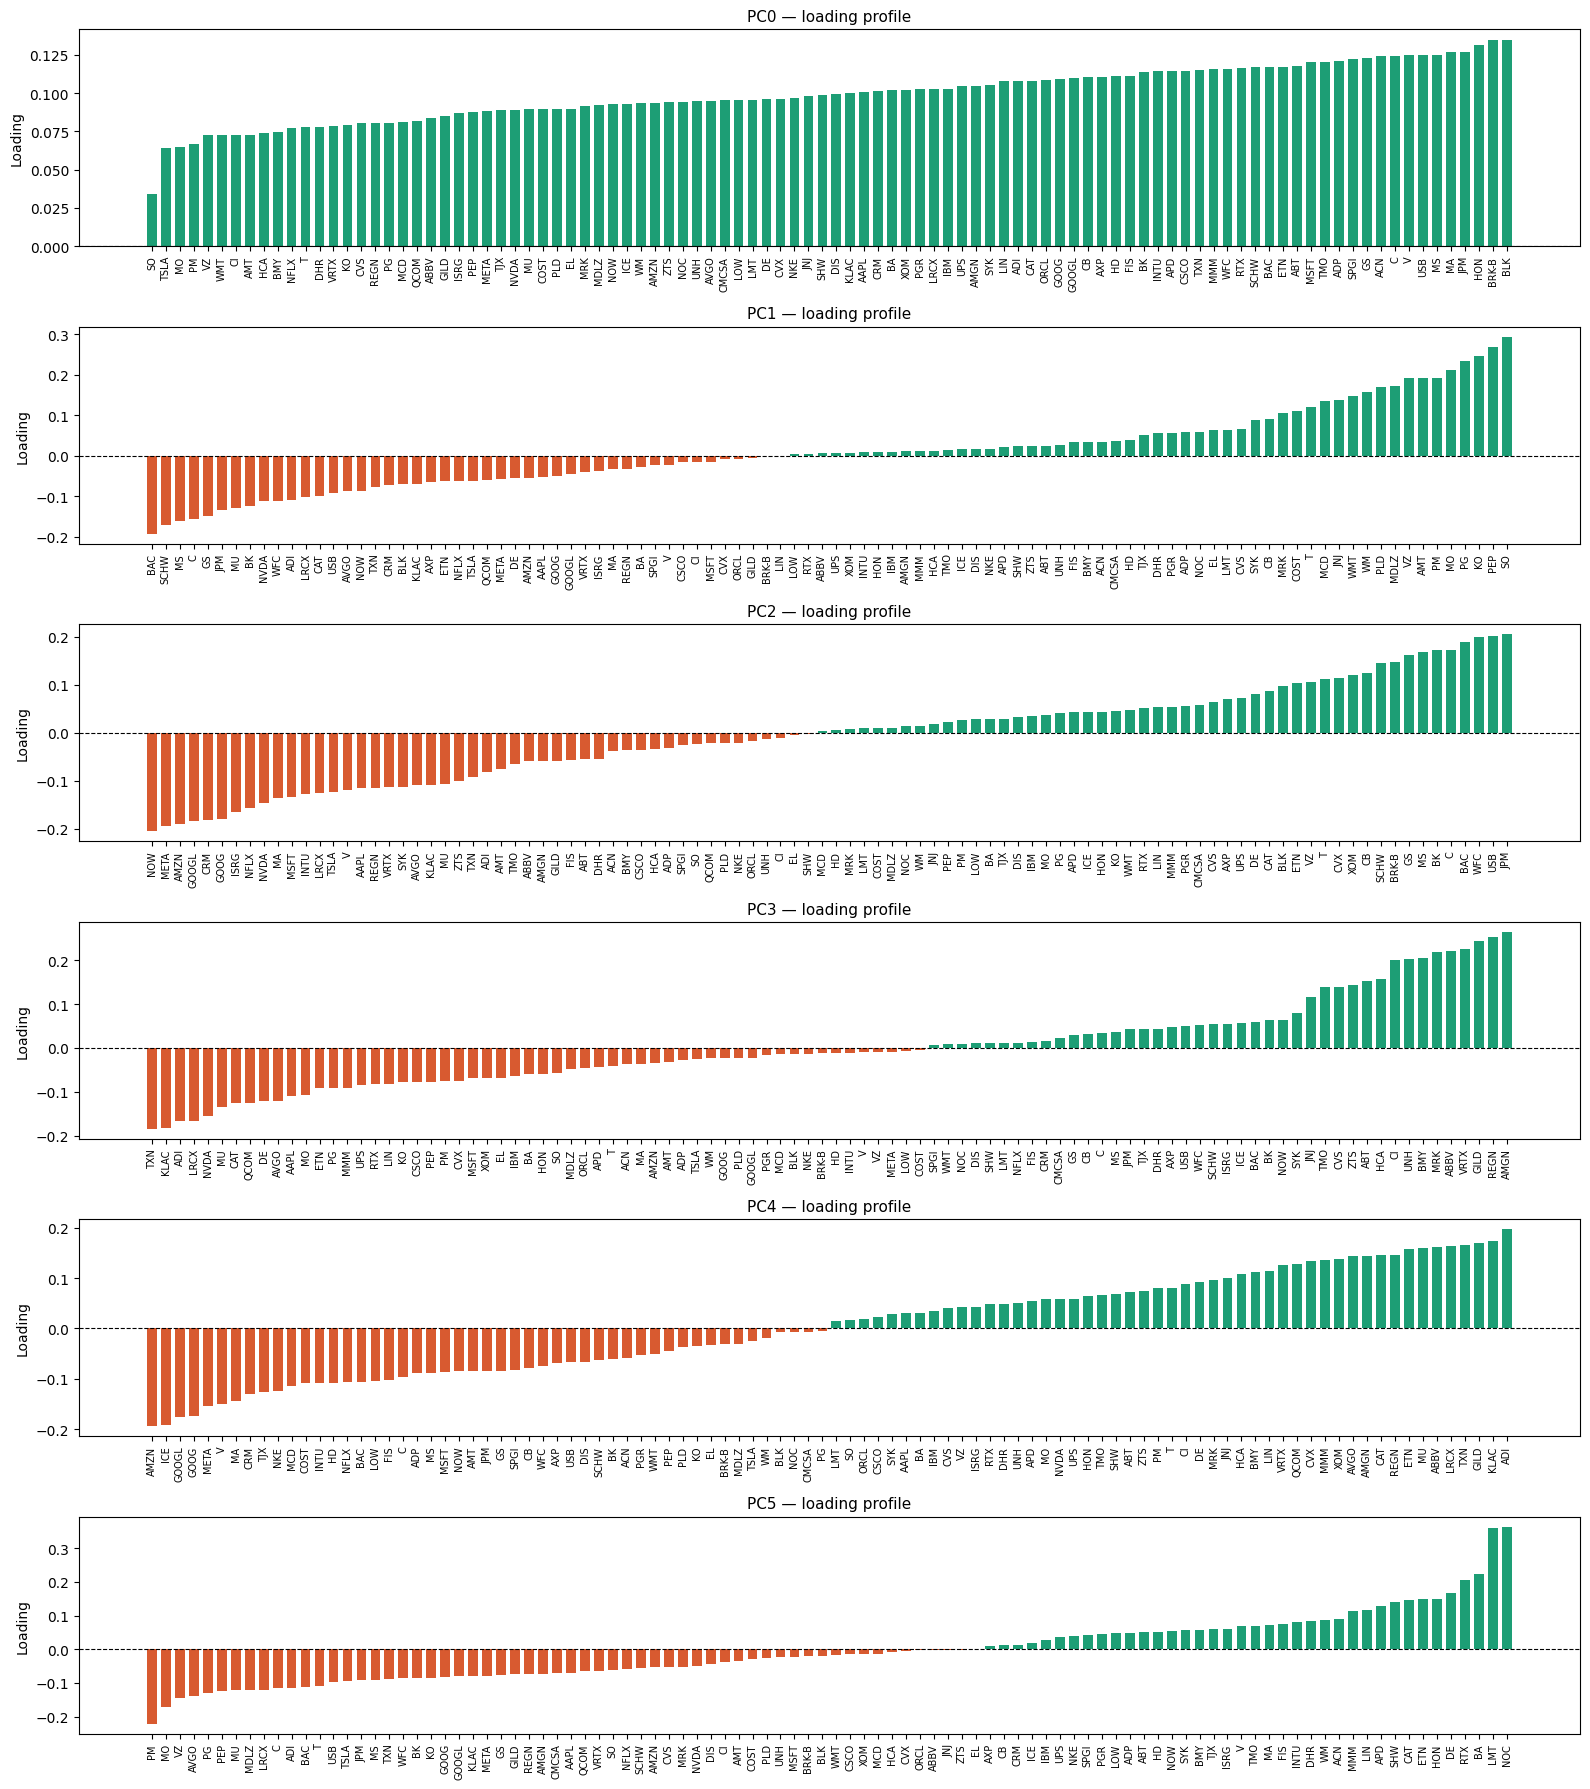

In [612]:
from matplotlib import pyplot as plt


fig, axes = plt.subplots(n_signal, 1, figsize=(16, 3 * n_signal))

for i, pc in enumerate(loadings.index):
    row    = loadings.loc[pc].sort_values()
    colors = ['#D85A30' if v < 0 else '#1D9E75' for v in row.values]
    
    axes[i].bar(row.index, row.values, color=colors, width=0.7)
    axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{pc} — loading profile', fontsize=11)
    axes[i].set_xticks(range(len(row)))
    axes[i].set_xticklabels(row.index, rotation=90, fontsize=7)
    axes[i].set_ylabel('Loading')

plt.tight_layout()
plt.show()

#### PCs Growth 

In [613]:
# Rolling window parameters
window  = 252        # 1 trading year
step    = 21         # roll forward 1 month at a time

dates        = []
pc0_shares   = []
n_signals    = []
enbs         = []

for start in range(0, T - window, step):
    end     = start + window
    window_returns = returns_scaled[start:end, :]

    # PCA on this window
    pca_roll = PCA()
    pca_roll.fit(window_returns)

    ev_roll  = pca_roll.explained_variance_
    evec_roll = pca_roll.components_

    # Marchenko-Pastur for this window
    T_w, N_w      = window_returns.shape
    lam_noise     = (1 + np.sqrt(N_w / T_w))**2
    sig_mask      = ev_roll > lam_noise
    n_sig         = sig_mask.sum()

    sig_ev        = ev_roll[sig_mask]
    sig_evec      = evec_roll[sig_mask]

    # PC0 share of total explained variance
    pc0_share     = sig_ev[0] / sig_ev.sum()

    # ENB of equal-weighted portfolio in this window
    betas_roll    = sig_evec @ weights
    rc_roll       = (betas_roll**2) * sig_ev
    p_roll        = rc_roll / rc_roll.sum()
    enb_roll      = np.exp(-np.sum(p_roll * np.log(p_roll + 1e-10)))

    # Record date at end of window
    dates.append(returns.index[end - 1])
    pc0_shares.append(pc0_share)
    n_signals.append(n_sig)
    enbs.append(enb_roll)

# Build results DataFrame
roll_df = pd.DataFrame({
    'PC0_share' : pc0_shares,
    'N_signal'  : n_signals,
    'ENB'       : enbs
}, index=dates)

print(roll_df.describe().round(4))

       PC0_share  N_signal      ENB
count    60.0000   60.0000  60.0000
mean      0.7166    4.3833   1.0438
std       0.0986    1.0430   0.0581
min       0.4854    2.0000   1.0007
25%       0.6779    4.0000   1.0079
50%       0.7297    4.0000   1.0193
75%       0.7849    5.0000   1.0428
max       0.8787    6.0000   1.2849


C:\Users\PC\AppData\Local\Temp\ipykernel_268364\329756210.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='upper left', fontsize=9)


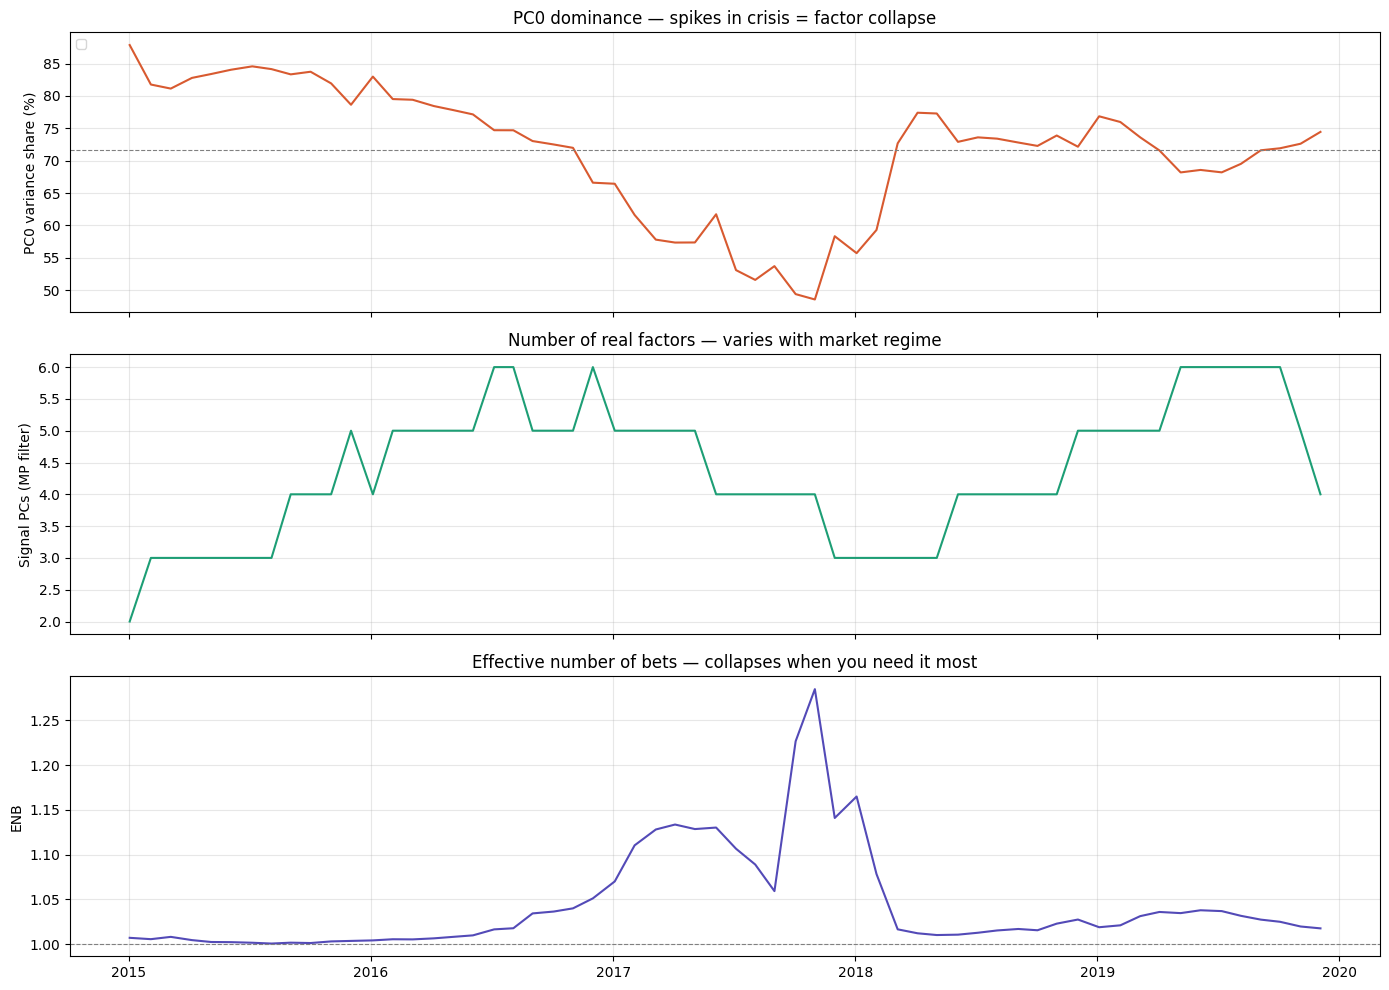

In [614]:
# Plot all three rolling metrics
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Panel 1 — PC0 dominance over time
axes[0].plot(roll_df.index, roll_df['PC0_share'] * 100,
             color='#D85A30', linewidth=1.5)
axes[0].axhline(roll_df['PC0_share'].mean() * 100,
                linestyle='--', color='gray', linewidth=0.8)
axes[0].set_ylabel('PC0 variance share (%)')
axes[0].set_title('PC0 dominance — spikes in crisis = factor collapse')
axes[0].grid(True, alpha=0.3)

# Panel 2 — number of signal PCs over time
axes[1].plot(roll_df.index, roll_df['N_signal'],
             color='#1D9E75', linewidth=1.5)
axes[1].set_ylabel('Signal PCs (MP filter)')
axes[1].set_title('Number of real factors — varies with market regime')
axes[1].grid(True, alpha=0.3)

# Panel 3 — rolling ENB
axes[2].plot(roll_df.index, roll_df['ENB'],
             color='#534AB7', linewidth=1.5)
axes[2].axhline(1.0, linestyle='--', color='gray', linewidth=0.8)
axes[2].set_ylabel('ENB')
axes[2].set_title('Effective number of bets — collapses when you need it most')
axes[2].grid(True, alpha=0.3)

axes[0].legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## PC Risk Parity Portfolio

In [615]:
from scipy.optimize import minimize

# signal eigenvectors and eigenvalues from your full-sample PCA
V = signal_eigenvectors.values   # shape: (7, 97)
L = signal_eigenvalues.values    # shape: (7,)

def risk_contributions(w):
    betas = V @ w
    rc    = (betas**2) * L
    return rc / rc.sum()

def objective(w):
    rc     = risk_contributions(w)
    target = np.ones(n_signal) / n_signal
    return np.sum((rc - target)**2)

# cap each asset at 10% maximum weight
cap = 0.1

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds      = [(0.001, cap)] * N
w0          = np.ones(N) / N

result = minimize(
    objective, w0,
    method      = 'SLSQP',
    bounds      = bounds,
    constraints = constraints,
    options     = {'maxiter': 1000, 'ftol': 1e-12}
)

w_pcrp = result.x

print(f"Optimization success : {result.success}")
print(f"Max weight           : {w_pcrp.max():.4f}  ({tickers[w_pcrp.argmax()]})")
print(f"Non-zero weights     : {(w_pcrp > 0.001).sum()}")
# Compute ENB for PCRP
betas_pcrp = signal_eigenvectors.values @ w_pcrp
rc_pcrp = (betas_pcrp**2) * signal_eigenvalues.values
var_shares = rc_pcrp / rc_pcrp.sum()
p_pcrp = var_shares
enb_pcrp = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

print(f"ENB                  : {enb_pcrp:.4f}")

Optimization success : True
Max weight           : 0.1000  (PG)
Non-zero weights     : 70
ENB                  : 2.7584


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\optimize\_slsqp_py.py:492: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_eq = vstack([con['jac'](x, *con['args'])


In [616]:
pcrp_returns = returns_F.values @ w_pcrp
pcrp_returns = pd.Series(pcrp_returns, index=returns_F.index)
pcrp_returns.describe()

count    1592.000000
mean        0.000331
std         0.010821
min        -0.098964
25%        -0.004567
50%         0.000657
75%         0.005230
max         0.078909
dtype: float64

In [617]:
pcrp_cumulative = (1 + pcrp_returns).cumprod()
pcrp_cumulative

Date
2019-12-31    1.001003
2020-01-02    0.994085
2020-01-03    0.991698
2020-01-06    0.994089
2020-01-07    0.989851
                ...   
2026-04-27    1.486946
2026-04-28    1.511086
2026-04-29    1.507759
2026-04-30    1.539730
2026-05-01    1.542932
Length: 1592, dtype: float64

In [618]:
pcrp_ann_return = pcrp_returns.mean() * 252
pcrp_ann_vol    = pcrp_returns.std()  * np.sqrt(252)
pcrp_sharpe = pcrp_ann_return / pcrp_ann_vol

print(f"Annualized Return : {pcrp_ann_return:.4f}")
print(f"Annualized Vol    : {pcrp_ann_vol:.4f}")
print(f"Sharpe Ratio : {pcrp_sharpe:.4f}")

Annualized Return : 0.0835
Annualized Vol    : 0.1718
Sharpe Ratio : 0.4859


In [619]:
pcrp_peak     = pcrp_cumulative.cummax()
pcrp_drawdown = (pcrp_cumulative - pcrp_peak) / pcrp_peak
pcrp_mdd      = pcrp_drawdown.min()

print(f"Max Drawdown : {pcrp_mdd:.2f}")

Max Drawdown : -0.32


## Risk Contribution pcrp

In [620]:
betas_pcrp  = signal_eigenvectors.values @ w_pcrp
rc_pcrp     = (betas_pcrp**2) * signal_eigenvalues.values
var_shares  = rc_pcrp / rc_pcrp.sum()
p_pcrp      = var_shares
enb_pcrp    = np.exp(-np.sum(p_pcrp * np.log(p_pcrp + 1e-10)))

risk_df = pd.DataFrame({
    'Variance_Share' : var_shares,
    'Risk_Contrib'   : rc_pcrp
}, index=[f'PC{i} — {pc_labels[f"PC{i}"]}' for i in range(n_signal)])

print(risk_df.round(4))
print(f"\nENB PCRP             : {enb_pcrp:.4f}")
betas_ew     = signal_eigenvectors.values @ weights
rc_ew        = (betas_ew**2) * signal_eigenvalues.values
var_shares_ew = rc_ew / rc_ew.sum()
enb_ew       = np.exp(-np.sum(var_shares_ew * np.log(var_shares_ew + 1e-10)))

print(f"ENB Equal-Weighted   : {enb_ew:.4f}")
print(f"Diversification Ratio: {enb_pcrp/N*100:.2f}%")

                                      Variance_Share  Risk_Contrib
PC0 — Market Beta                             0.5049        0.2079
PC1 — Defensives vs Financials                0.4054        0.1670
PC2 — Banking vs Tech Growth                  0.0121        0.0050
PC3 — Biotech vs Semiconductors               0.0205        0.0084
PC4 — Semiconductor vs Mega Cap Tech          0.0015        0.0006
PC5 — Defense vs Tobacco and Telecom          0.0556        0.0229

ENB PCRP             : 2.7584
ENB Equal-Weighted   : 1.0142
Diversification Ratio: 2.81%


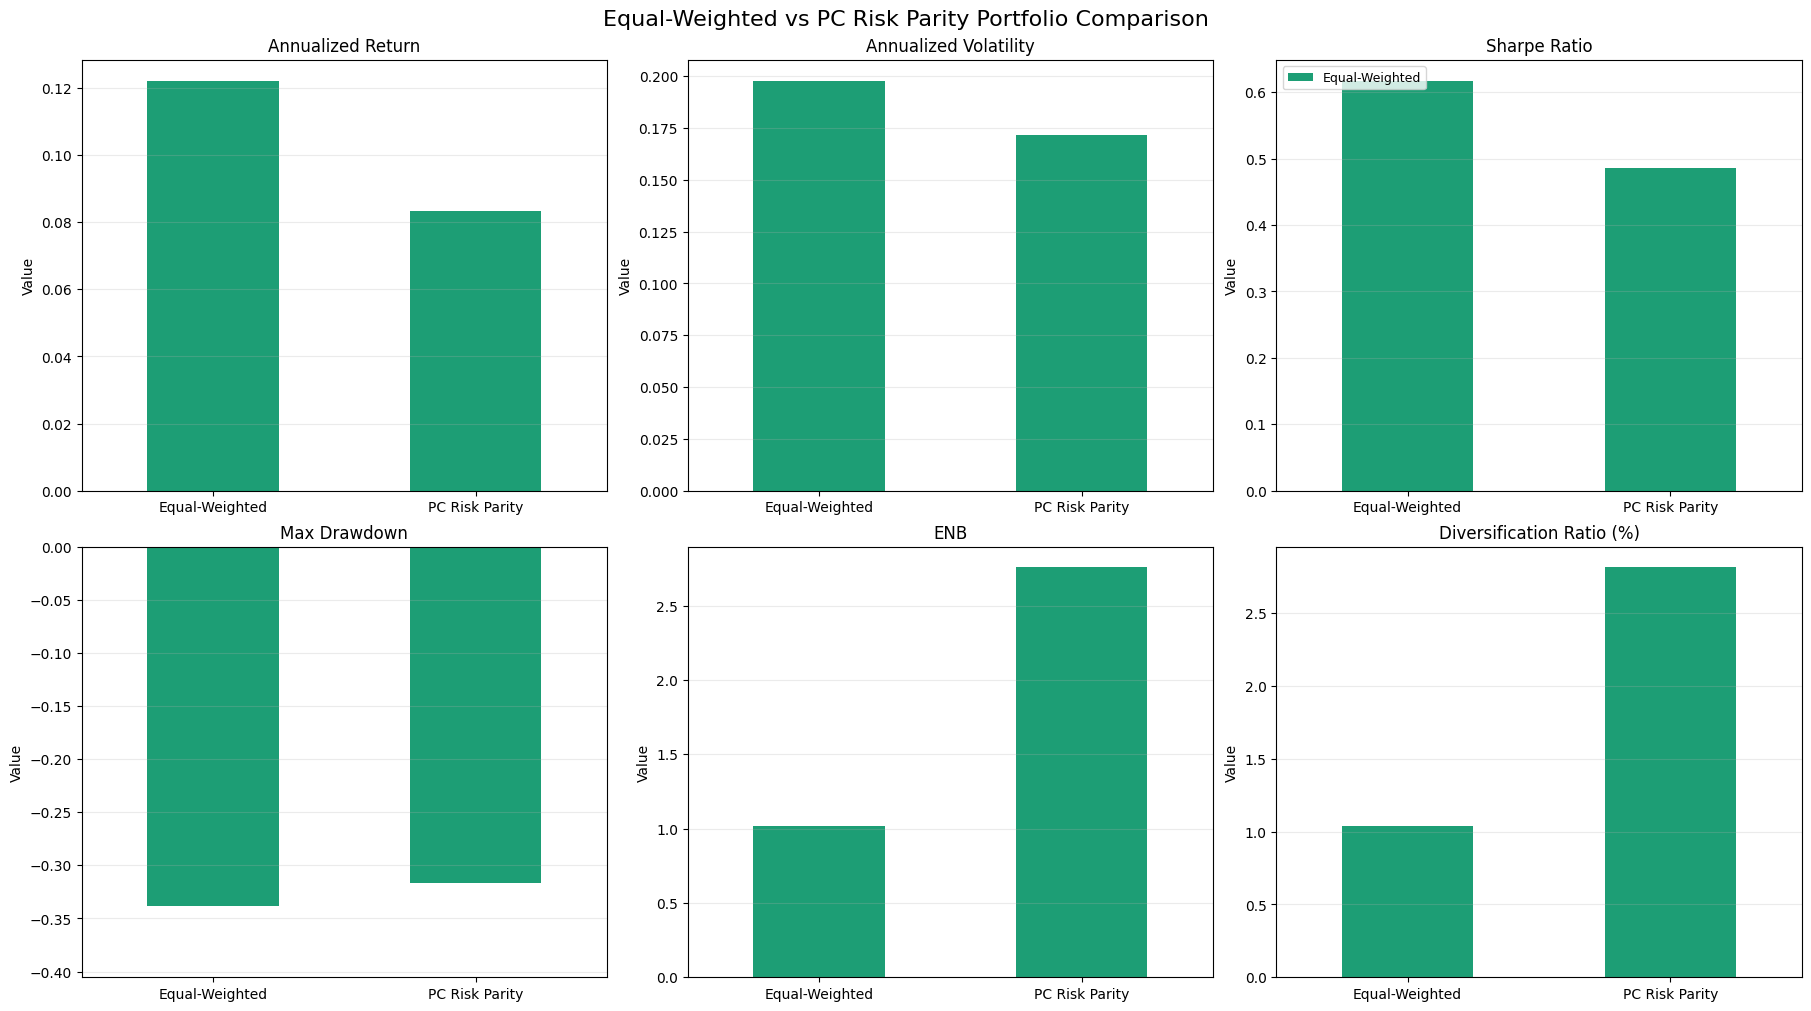

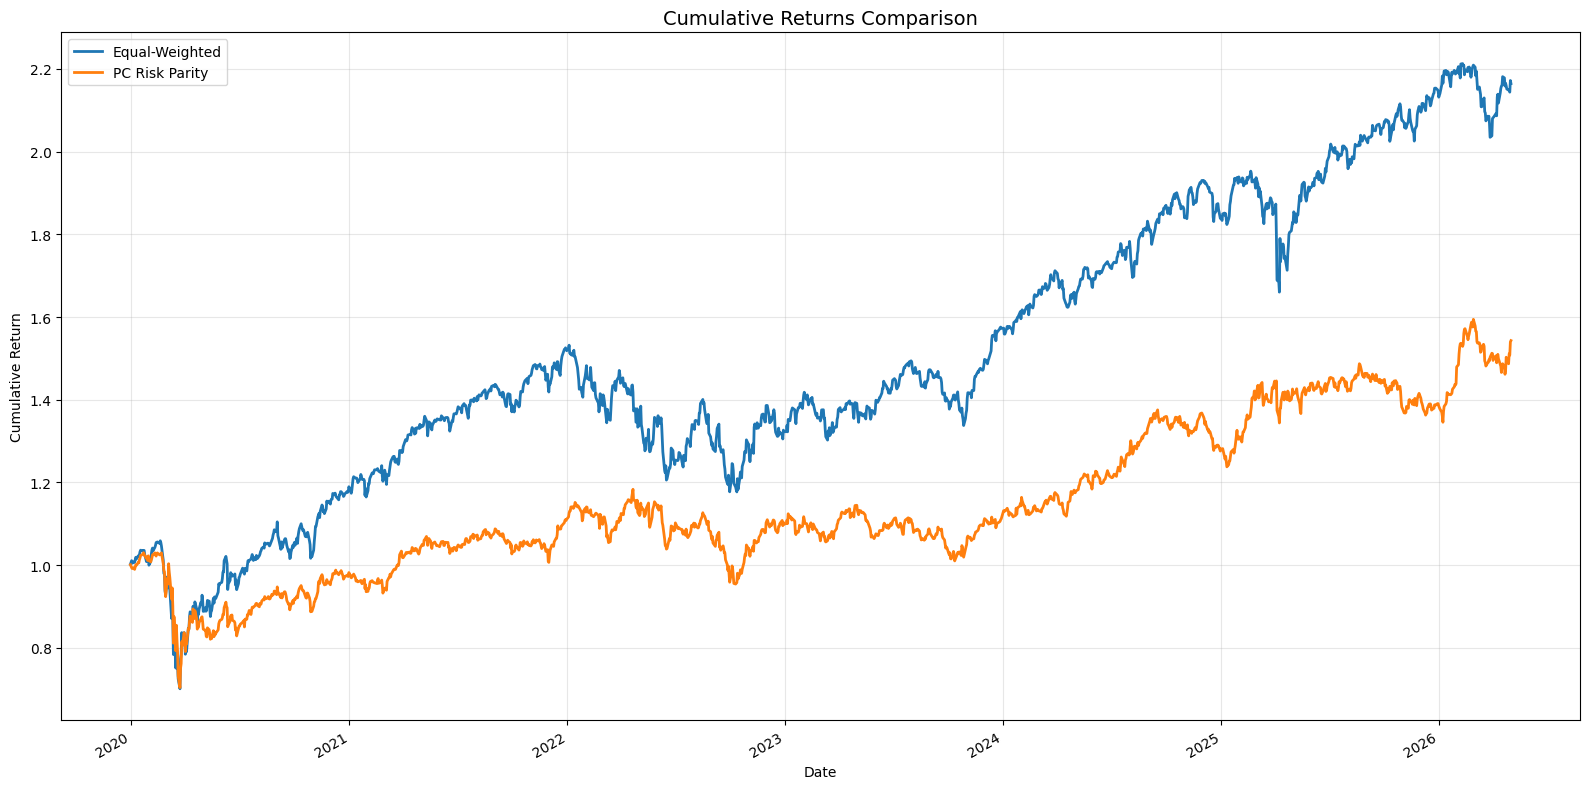

In [621]:
comparison = pd.DataFrame({
    'Equal-Weighted': [
        ew_ann_return,
        ew_ann_vol,
        ew_sharpe,
        ew_drawdown.min(),
        enb_ew,
        enb_ew / N * 100
    ],
    'PC Risk Parity': [
        pcrp_ann_return,
        pcrp_ann_vol,
        pcrp_sharpe,
        pcrp_mdd,
        enb_pcrp,
        enb_pcrp / N * 100
    ]
}, index=[
    'Annualized Return',
    'Annualized Volatility',
    'Sharpe Ratio',
    'Max Drawdown',
    'ENB',
    'Diversification Ratio (%)'
])

fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

for ax, metric in zip(axes.flatten(), comparison.index):
    comparison.loc[[metric]].T.plot(
        kind='bar',
        ax=ax,
        color=['#1D9E75', '#D85A30'],
        legend=False,
        rot=0
    )
    ax.set_title(metric)
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.25)
    if metric == 'Max Drawdown':
        ax.set_ylim(comparison.loc['Max Drawdown'].min() * 1.2, 0)

for ax in axes[-1, :]:
    ax.set_xlabel('')

axes[0, 2].legend(comparison.columns, loc='upper left', fontsize=9)

plt.suptitle('Equal-Weighted vs PC Risk Parity Portfolio Comparison', fontsize=16)
plt.show()

# Add cumulative returns comparison
cum_returns_comparison = pd.DataFrame({
    'Equal-Weighted': cum_returns,
    'PC Risk Parity': pcrp_cumulative
})

fig, ax = plt.subplots(figsize=(16, 8))
cum_returns_comparison.plot(ax=ax, linewidth=2)
ax.set_title('Cumulative Returns Comparison', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Return')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [622]:
# save final weights
np.save('w_pcrp_final.npy', w_pcrp)
np.save('w_ew_final.npy',   weights)
print("Weights saved.")

Weights saved.


## Crisis stress test 

In [623]:
crises = {
    'COVID Crash'    : ('2020-02-01', '2020-04-30'),
    'Rate Shock 2022': ('2022-01-01', '2022-12-31')
}

results = []

for crisis_name, (start, end) in crises.items():

    # --- Portfolio returns (from test set) ---
    ew_crisis   = portfolio_returns[start:end]
    pcrp_crisis = pcrp_returns[start:end]

    if len(ew_crisis) == 0:
        print(f"WARNING: No data for {crisis_name}")
        continue

    # --- Cumulative wealth ---
    ew_cum   = (1 + ew_crisis).cumprod()
    pcrp_cum = (1 + pcrp_crisis).cumprod()

    # --- Total return ---
    ew_total   = ew_cum.iloc[-1] - 1
    pcrp_total = pcrp_cum.iloc[-1] - 1

    # --- Sharpe (rf = 0 for now) ---
    ew_sharpe_c   = (ew_crisis.mean() / ew_crisis.std()) * np.sqrt(252)
    pcrp_sharpe_c = (pcrp_crisis.mean() / pcrp_crisis.std()) * np.sqrt(252)

    # --- Maximum Drawdown ---
    ew_mdd_c   = ((ew_cum - ew_cum.cummax()) / ew_cum.cummax()).min()
    pcrp_mdd_c = ((pcrp_cum - pcrp_cum.cummax()) / pcrp_cum.cummax()).min()

    # --- ENB during crisis window ---
    # slice from test returns DataFrame using DatetimeIndex
    crisis_window = returns_F.loc[start:end]

    # scale using TRAINING scaler only — no refitting
    crisis_scaled = scaler.transform(crisis_window)

    # fit PCA on crisis window
    pca_c = PCA()
    pca_c.fit(crisis_scaled)

    ev_c  = pca_c.explained_variance_
    evc_c = pca_c.components_

    # Marchenko-Pastur threshold for this window
    T_c, N_c = crisis_scaled.shape
    lam_c    = (1 + np.sqrt(N_c / T_c))**2
    sig_c    = ev_c > lam_c
    ev_sig   = ev_c[sig_c]
    evc_sig  = evc_c[sig_c]

    # ENB equal-weighted
    b_ew     = evc_sig @ weights
    rc_ew    = (b_ew**2) * ev_sig
    p_ew     = rc_ew / rc_ew.sum()
    enb_ew_c = np.exp(-np.sum(p_ew * np.log(p_ew + 1e-10)))

    # ENB PCRP
    b_pc     = evc_sig @ w_pcrp
    rc_pc    = (b_pc**2) * ev_sig
    p_pc     = rc_pc / rc_pc.sum()
    enb_pc_c = np.exp(-np.sum(p_pc * np.log(p_pc + 1e-10)))

    results.append({
        'Crisis'            : crisis_name,
        'EW Total Return'   : ew_total,
        'PCRP Total Return' : pcrp_total,
        'EW MDD'            : ew_mdd_c,
        'PCRP MDD'          : pcrp_mdd_c,
        'EW Sharpe'         : ew_sharpe_c,
        'PCRP Sharpe'       : pcrp_sharpe_c,
        'EW ENB'            : enb_ew_c,
        'PCRP ENB'          : enb_pc_c,
        'Signal PCs'        : sig_c.sum()
    })

crisis_df = pd.DataFrame(results).set_index('Crisis')
print(crisis_df.round(4).T)

Crisis             COVID Crash  Rate Shock 2022
EW Total Return        -0.1300          -0.1504
PCRP Total Return      -0.1472          -0.0108
EW MDD                 -0.3602          -0.2464
PCRP MDD               -0.3164          -0.1936
EW Sharpe              -0.5690          -0.6169
PCRP Sharpe            -0.8627           0.0179
EW ENB                  1.0155           1.0498
PCRP ENB                1.5978           3.2696
Signal PCs             16.0000          12.0000


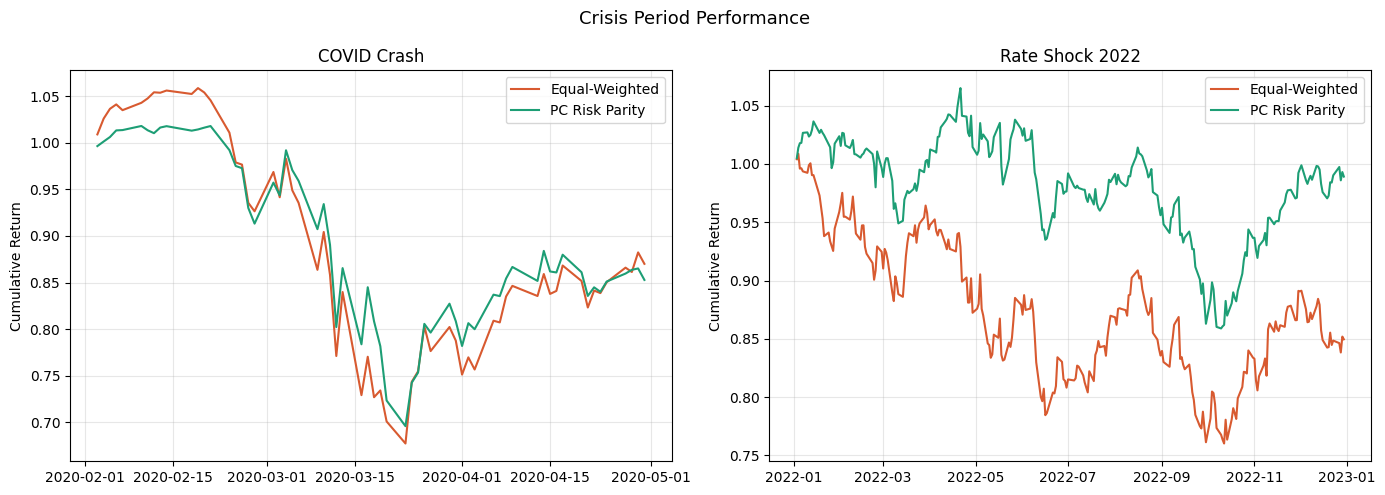

In [624]:
# plot crisis cumulative returns side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (crisis_name, (start, end)) in enumerate(crises.items()):
    ew_c   = (1 + portfolio_returns[start:end]).cumprod()
    pcrp_c = (1 + pcrp_returns[start:end]).cumprod()
    
    axes[i].plot(ew_c,   label='Equal-Weighted', color='#D85A30', linewidth=1.5)
    axes[i].plot(pcrp_c, label='PC Risk Parity', color='#1D9E75', linewidth=1.5)
    axes[i].set_title(crisis_name)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylabel('Cumulative Return')

plt.suptitle('Crisis Period Performance', fontsize=13)
plt.tight_layout()
plt.show()